In [1]:
library(data.table)
library(ggplot2)
library(ggrastr)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')

In [2]:
.libPaths()

[1] "/gpfs3/well/lindgren/users/mmq446/conda/skylake/envs/rpy/lib/R/library"

In [3]:
library(data.table)

In [4]:
# readin helpers
zcat <- function(path,...){
    cmd = paste("zcat", path)
    return(fread(cmd = cmd,...))
}


In [5]:
# variants
files_external <- list.files('data/variants/',pattern = 'ukb_wes_200k_external_qc_chr[0-9]+.tsv.bgz', full.names = TRUE)

In [8]:
files_external

[1] "data/variants//ukb_wes_200k_external_qc_chr1.tsv.bgz" 
 [2] "data/variants//ukb_wes_200k_external_qc_chr10.tsv.bgz"
 [3] "data/variants//ukb_wes_200k_external_qc_chr11.tsv.bgz"
 [4] "data/variants//ukb_wes_200k_external_qc_chr12.tsv.bgz"
 [5] "data/variants//ukb_wes_200k_external_qc_chr13.tsv.bgz"
 [6] "data/variants//ukb_wes_200k_external_qc_chr14.tsv.bgz"
 [7] "data/variants//ukb_wes_200k_external_qc_chr15.tsv.bgz"
 [8] "data/variants//ukb_wes_200k_external_qc_chr16.tsv.bgz"
 [9] "data/variants//ukb_wes_200k_external_qc_chr17.tsv.bgz"
[10] "data/variants//ukb_wes_200k_external_qc_chr18.tsv.bgz"
[11] "data/variants//ukb_wes_200k_external_qc_chr19.tsv.bgz"
[12] "data/variants//ukb_wes_200k_external_qc_chr20.tsv.bgz"
[13] "data/variants//ukb_wes_200k_external_qc_chr21.tsv.bgz"
[14] "data/variants//ukb_wes_200k_external_qc_chr22.tsv.bgz"
[15] "data/variants//ukb_wes_200k_external_qc_chr3.tsv.bgz" 
[16] "data/variants//ukb_wes_200k_external_qc_chr5.tsv.bgz" 
[17] "data/variants//ukb_wes_200k_external_qc_chr6.tsv.bgz" 
[18] "data/variants//ukb_wes_200k_external_qc_chr7.tsv.bgz" 
[19] "data/variants//ukb_wes_200k_external_qc_chr8.tsv.bgz" 
[20] "data/variants//ukb_wes_200k_external_qc_chr9.tsv.bgz"

In [15]:
d <- zcat(files_external[1])

In [18]:
sum(!is.na(d$gb_AC))

[1] 542381

In [19]:
colnames(d)

[1] "locus"                       "alleles"                    
 [3] "rsid"                        "qual"                       
 [5] "filters"                     "info.AF"                    
 [7] "info.AQ"                     "info.AC"                    
 [9] "info.AN"                     "info.ExcessHet"             
[11] "inGnomAD"                    "imputed_info"               
[13] "variant_qc.dp_stats.mean"    "variant_qc.dp_stats.stdev"  
[15] "variant_qc.dp_stats.min"     "variant_qc.dp_stats.max"    
[17] "variant_qc.gq_stats.mean"    "variant_qc.gq_stats.stdev"  
[19] "variant_qc.gq_stats.min"     "variant_qc.gq_stats.max"    
[21] "variant_qc.AC"               "variant_qc.AF"              
[23] "variant_qc.AN"               "variant_qc.homozygote_count"
[25] "variant_qc.call_rate"        "variant_qc.n_called"        
[27] "variant_qc.n_not_called"     "variant_qc.n_filtered"      
[29] "variant_qc.n_het"            "variant_qc.n_non_ref"       
[31] "variant_qc.het_freq_hwe"     "variant_qc.p_value_hwe"     
[33] "gb_AC"                       "gb_AF"                      
[35] "gb_gene"                     "gb_annotation"

In [39]:
# how many of the variants are in gnomAD and GB
summarize_external_db <- function(d, as_pct = TRUE){
    
    stopifnot('inGnomAD' %in% colnames(d))
    stopifnot('gb_AC' %in% colnames(d))
    stopifnot('locus' %in% colnames(d))
    chrom <- unique(unlist(strsplit(d$locus, split = ':'))[1])
    total <- nrow(d)
    in_gnomad <- sum(d$inGnomAD)
    in_gb <- sum(!is.na(d$gb_AC))
    in_both <- sum(d$inGnomAD & !is.na(d$gb_AC))
    if (as_pct){
        in_gnomad <- in_gnomad / total
        in_gb <- in_gb / total
        in_both <- in_both / total
    }
    return(data.frame(chrom, in_gnomad, in_gb, in_both, total))
}




In [40]:
sum(d$inGnomAD)

[1] 424704

In [41]:
summarize_external_db(d)

chrom,in_gnomad,in_gb,in_both,total
<chr>,<dbl>,<dbl>,<dbl>,<int>
chr1,0.4636846,0.5921623,0.3094408,915933


[1] 0.5921623

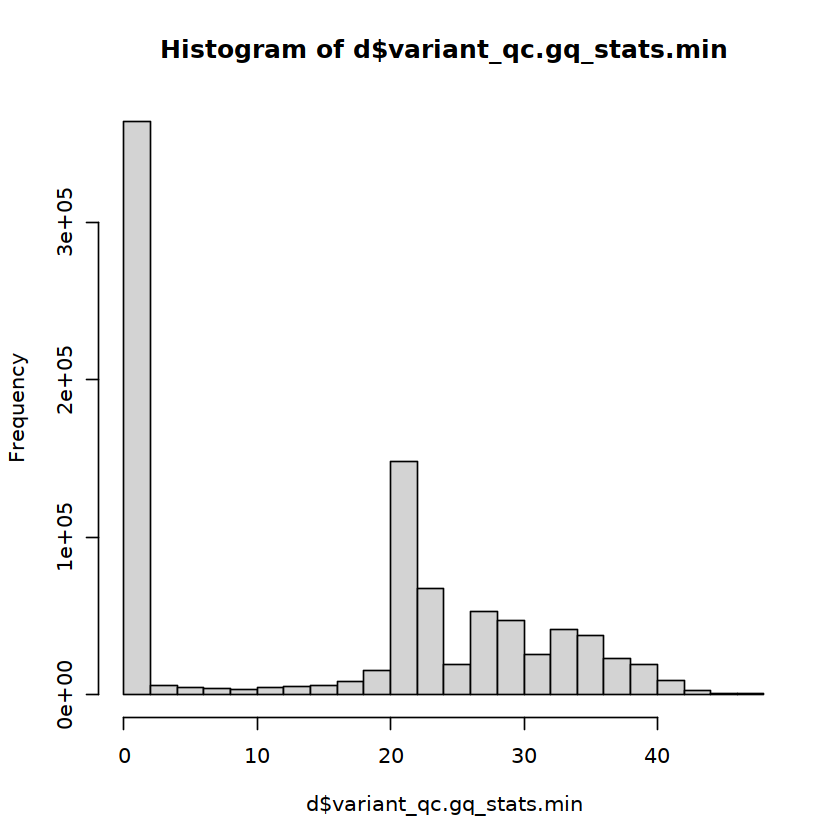

In [43]:
hist(d$variant_qc.gq_stats.min)

In [9]:
# variants
files_qc <- list.files('data/qc/',pattern = 'ukb_wes_200k_chr[0-9]+_variants_summary_phased.tsv.bgz', full.names = TRUE)

In [10]:
d <- do.call(rbind,lapply(files_qc, function(file) zcat(file)))

In [11]:
d$n_URV_PTV_LC <- NULL

In [12]:
apply(d[,-1], 2, quantile, probs = c(0.025, 0.5, 0.975))

,n_coding_URV_SNP,n_coding_URV_indel,n_URV_PTV,n_URV_damaging_missense,n_URV_other_missense,n_URV_synonymous,n_URV_non_coding
2.5%,194,0,0,0,93,99,202
50%,613,4,2,2,272,344,659
97.5%,1491,13,13,7,697,787,1379


In [13]:
d$s[1]

[1] 1000028

In [14]:
d_aggr <- aggregate(.~s, d, sum)

In [15]:
d_aggr_melted <- data.table::melt(d_aggr, id.var = 's')

Warning message in data.table::melt(d_aggr, id.var = "s"):
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(d_aggr). In the next version, this warning will become an error."


In [16]:
print(unique(d_aggr_melted$variable))

[1] n_coding_URV_SNP        n_coding_URV_indel      n_URV_PTV              
[4] n_URV_damaging_missense n_URV_other_missense    n_URV_synonymous       
[7] n_URV_non_coding       
7 Levels: n_coding_URV_SNP n_coding_URV_indel ... n_URV_non_coding


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



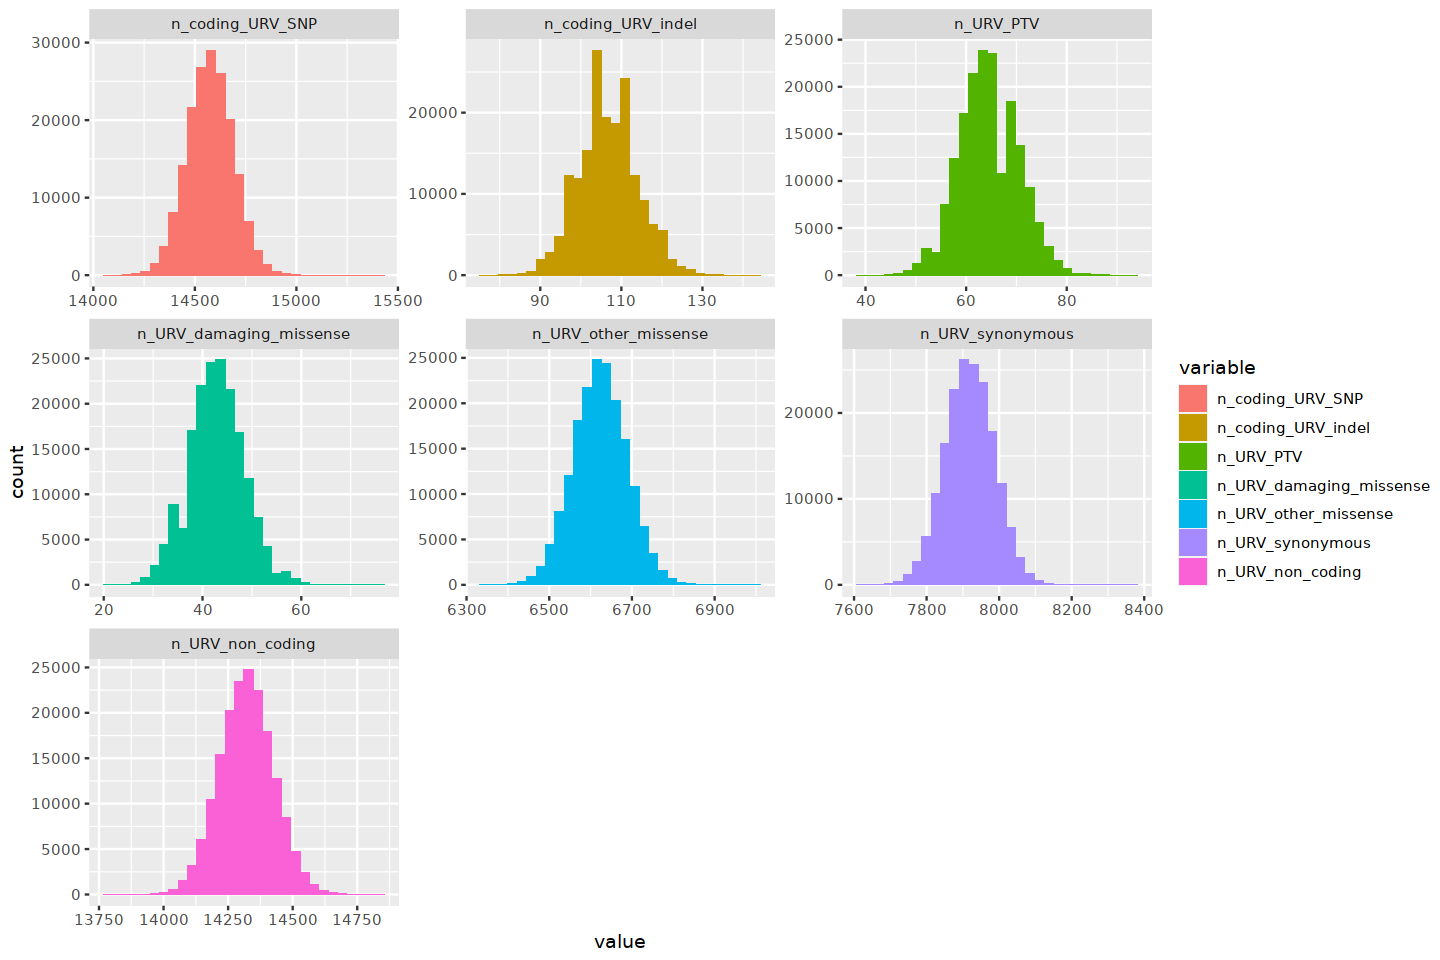

In [17]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(d_aggr_melted, aes(x = value, fill = variable)) +
    geom_histogram() +
    facet_wrap(~variable, scales = 'free')

s,variable,value
<int>,<fct>,<int>
1000028,n_coding_URV_SNP,14844
1000034,n_coding_URV_SNP,14841
1000087,n_coding_URV_SNP,14581
1000118,n_coding_URV_SNP,14658
1000120,n_coding_URV_SNP,14867
1000162,n_coding_URV_SNP,14704
1000171,n_coding_URV_SNP,14662
1000196,n_coding_URV_SNP,14680
1000254,n_coding_URV_SNP,14577


In [129]:
xx <- c('hello.vcf.bgz','hello.tsv.bgz')

In [135]:
in_ext = 'tsv.bgz'
regex = paste0('*.',in_ext,'$')
grepl(regex, xx)

[1] FALSE  TRUE

[1] "hello.vcg.bgz" "hello.tsv.bgz"

In [136]:
x <- zcat('derived/knockouts/211104/ukb_wes_200k_af50_chr10_ptv_knockouts.tsv.bgz')

In [142]:
sum(x$knockout)

[1] 23345

In [151]:
length(unique(x[x$csqs == 'HO']$s))

[1] 22024

[1] 196234

In [25]:
# variants
files_genes <- list.files('data/qc/',pattern = 'ukb_wes_200k_chr21_urv_by_genes_phased.tsv.bgz', full.names = TRUE)
#files_qc <- list.files('data/qc/',pattern = 'ukb_wes_200k_chr[0-9]+_urv_by_genes_phased.tsv.bgz', full.names = TRUE)
#d <- do.call(rbind,lapply(files_qc, function(file) zcat(file)))


In [30]:
#files_genes <- list.files('data/qc/',pattern = 'ukb_wes_200k_chr[0-9]+_urv_by_genes_phased.tsv.bgz', full.names = TRUE)
d_genes <- do.call(rbind,lapply(files_genes, function(file) zcat(file)))
d_genes$s <- NULL
d_genes_aggr <- aggregate(.~gene_id, d_genes, sum)
write.table(d_sample_aggr, 'derived/tables/sample_level_urv_count.tsv', quote = FALSE, row.names = FALSE) 
d_genes_aggr

gene_id,gene.n_coding_URV_SNP,gene.n_coding_URV_indel,gene.n_URV_PTV,gene.n_URV_PTV_LC,gene.n_URV_damaging_missense,gene.n_URV_other_missense,gene.n_URV_synonymous,gene.n_URV_non_coding
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000141956,807787,486,613,0,17,213890,593753,833815
ENSG00000141959,166960,67,122,0,2813,11173,152919,769839
ENSG00000142149,402009,34,49,0,4,73246,328744,245584
ENSG00000142156,417204,27,84,0,1822,171997,243328,2064865
ENSG00000142166,45949,38,27,0,27,44480,1453,798
ENSG00000142168,2214,20,20,0,177,1239,798,2080
ENSG00000142173,641952,179,112,0,3757,380294,257968,1733436
ENSG00000142182,5401,154,198,0,106,2405,2846,75403
ENSG00000142185,272419,1029,2536,0,1068,258933,10897,1295763


In [94]:
# Get knockout stats
#files_ko <- list.files('derived/knockouts/211106/',pattern = 'ukb_wes_200k_af02_chr7_ptv_knockouts.tsv.bgz', full.names = TRUE)
#
#
files_ko <- list.files('derived/knockouts/211110/',pattern = 'ukb_wes_200k_af02_chr[0-9]+_ptv_damaging_missense_knockouts.tsv.bgz', full.names = TRUE)
print(files_ko)

d <- do.call(rbind,lapply(files_ko, function(file) zcat(file)))

 [1] "derived/knockouts/211110//ukb_wes_200k_af02_chr10_ptv_damaging_missense_knockouts.tsv.bgz"
 [2] "derived/knockouts/211110//ukb_wes_200k_af02_chr11_ptv_damaging_missense_knockouts.tsv.bgz"
 [3] "derived/knockouts/211110//ukb_wes_200k_af02_chr12_ptv_damaging_missense_knockouts.tsv.bgz"
 [4] "derived/knockouts/211110//ukb_wes_200k_af02_chr13_ptv_damaging_missense_knockouts.tsv.bgz"
 [5] "derived/knockouts/211110//ukb_wes_200k_af02_chr14_ptv_damaging_missense_knockouts.tsv.bgz"
 [6] "derived/knockouts/211110//ukb_wes_200k_af02_chr15_ptv_damaging_missense_knockouts.tsv.bgz"
 [7] "derived/knockouts/211110//ukb_wes_200k_af02_chr16_ptv_damaging_missense_knockouts.tsv.bgz"
 [8] "derived/knockouts/211110//ukb_wes_200k_af02_chr17_ptv_damaging_missense_knockouts.tsv.bgz"
 [9] "derived/knockouts/211110//ukb_wes_200k_af02_chr18_ptv_damaging_missense_knockouts.tsv.bgz"
[10] "derived/knockouts/211110//ukb_wes_200k_af02_chr19_ptv_damaging_missense_knockouts.tsv.bgz"
[11] "derived/knockouts/211110

In [95]:
# translate genes into hgnc_symbol
hgnc_bridge <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/hgnc/211026_hgnc_ensgid_link.csv')
colnames(hgnc_bridge)[2] <- 'gene_id'
d <- merge(d,t hgnc_bridge, by = 'gene_id', all.x = TRUE)

In [96]:
# Load LOEUF deciles
constraints <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv')
constraints$loeuf <- constraints$oe_lof_upper 
constraints <- constraints[constraints$canonical == TRUE,]

# create deciles
deciles_loeuf_seq <- seq(0,1,by = 0.1)
deciles_loeuf <- quantile(constraints$loeuf, probs = deciles_loeuf_seq, na.rm = T)
constraints$decile <- cut(constraints$loeuf, deciles_loeuf)
levels(constraints$decile) <- deciles_loeuf_seq*100
constraints$decile_plot <-  paste0(constraints$decile,'-', as.numeric(as.character(constraints$decile))+10)
constraints$decile_plot[constraints$decile_plot == 'NA-NA'] <- NA


[1] 14301


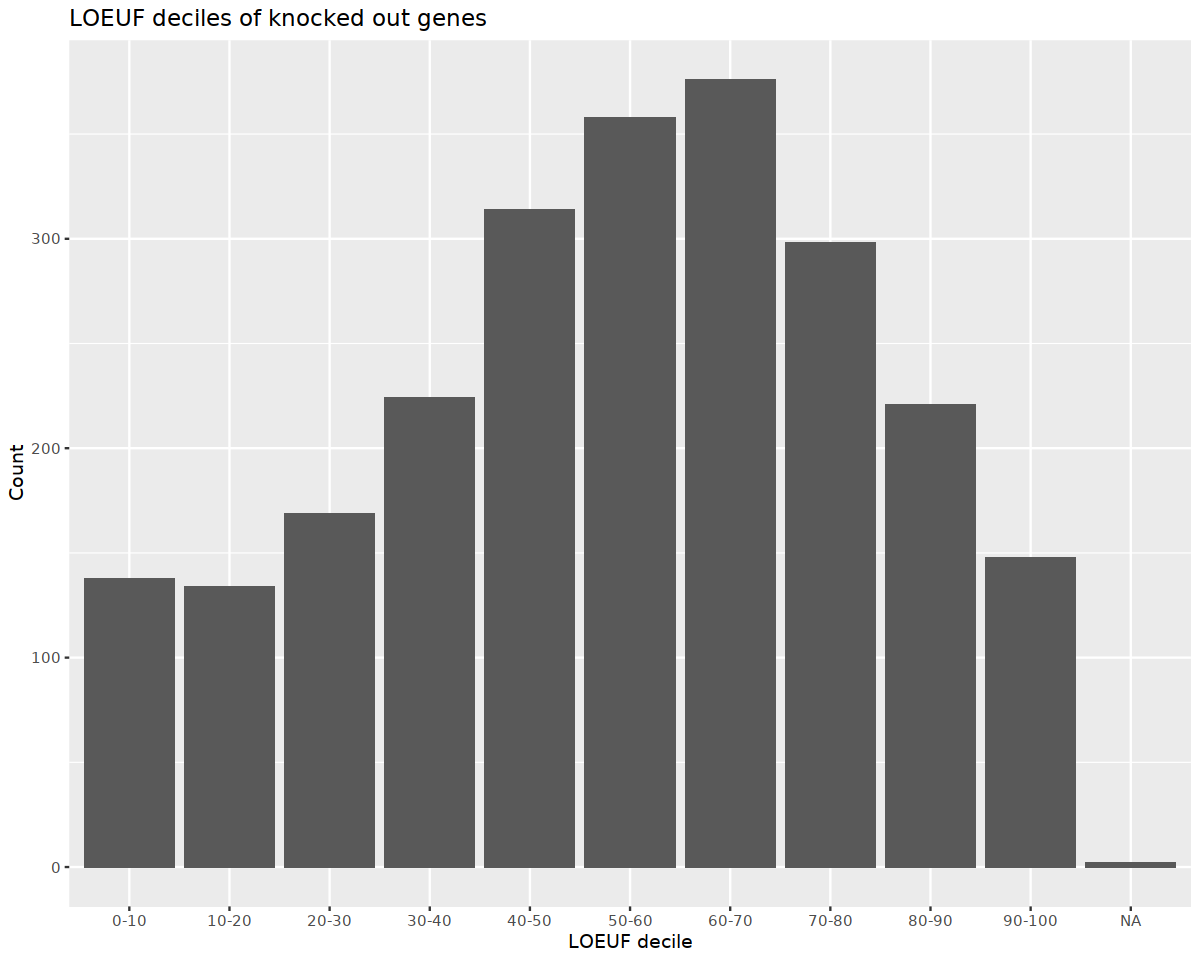

In [107]:
# Unique genes in LOEUF deciles
genes <- d$hgnc_symbol[d$knockout]
print(length(genes))
d_unique <- constraints[constraints$gene %in% genes]

options(repr.plot.width=10, repr.plot.height=8)
ggplot(d_unique, aes(x=decile_plot)) +
    geom_bar() +
    xlab('LOEUF decile') +
    ylab('Count') +
    ggtitle('LOEUF deciles of knocked out genes')

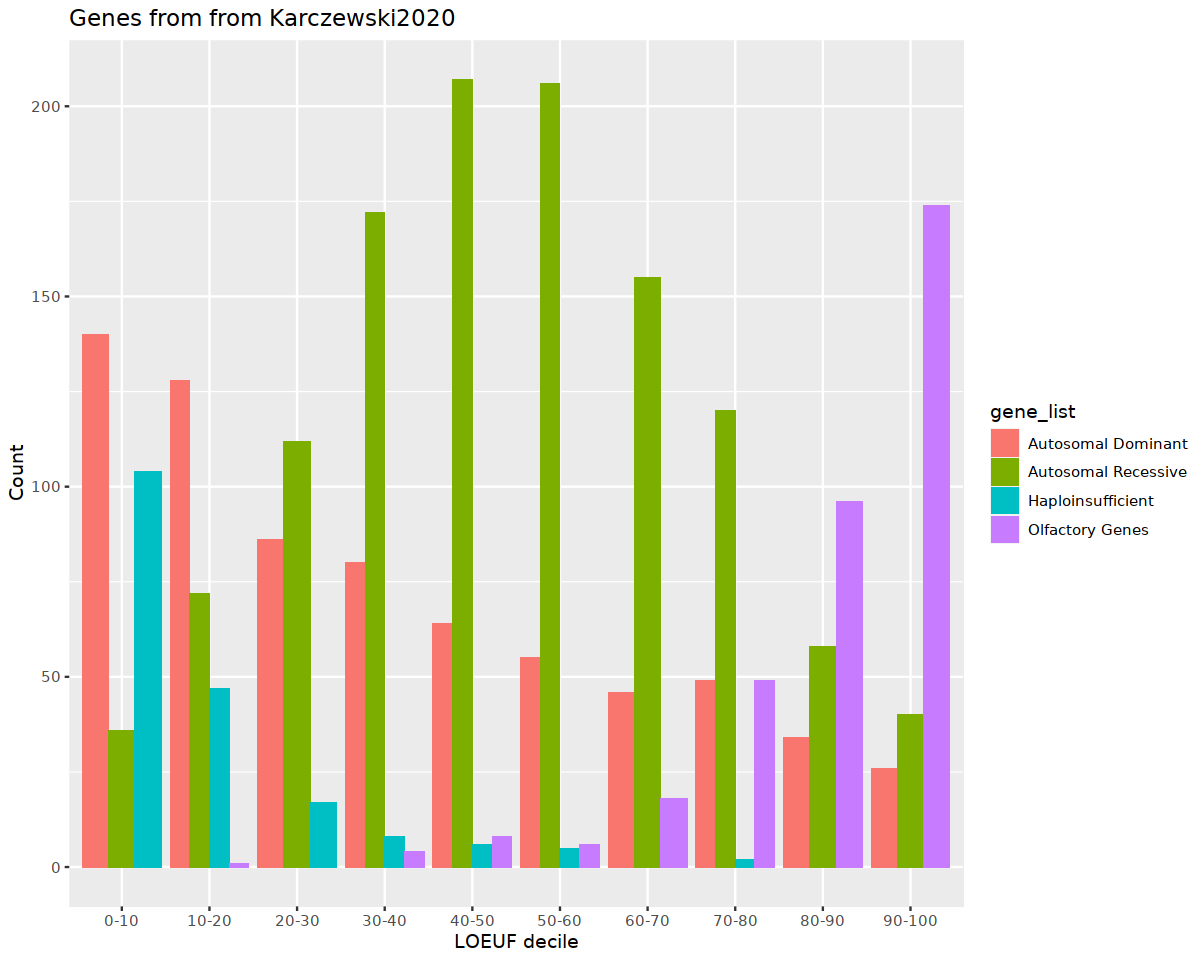

In [106]:
# Load geneset of haploinsufficient genes / recessive / dominant
geneset <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_13_gene_lists.tsv')
geneset$decile <- gsub('\\%','',geneset$oe_lof_upper_bin)

options(repr.plot.width=10, repr.plot.height=8)
ggplot(geneset, aes(x=decile, fill = gene_list)) +
    geom_bar(position = 'dodge') +
    xlab('LOEUF decile') +
    ylab('Count') +
    ggtitle('Genes from from Karczewski2020')


In [129]:
# Different genes
cancer <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/cosmic/Cancer_Gene_Census_Hallmarks_Of_Cancer.tsv')
#head(cancer)
#ggplot(cancer[cancer$GENE_NAME %in% genes,], aes(x=CELL_TYPE)) + 
#    geom_histogram()

head(cancer)

GENE_NAME,CELL_TYPE,PUBMED_PMID,HALLMARK,IMPACT,DESCRIPTION,CELL_LINE
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
ABI1,colorectal cancer,24913355,invasion and metastasis,promotes,"promotes tumour cell adhesion, extracellular matrix degradation and invasion",
ABI1,,10499589,function summary,,participates in the transduction of signals from Ras to Rac,
ABI1,,16025998,role in cancer,TSG,TSG,
ABI1,,9694699,role in cancer,fusion,fusion,
ABI1,,23552839,role in cancer,TSG,TSG,
ABI1,,9010225,suppression of growth,promotes,fibroblasts overexpressing e3B1 have reduced growth compared to matched controls,


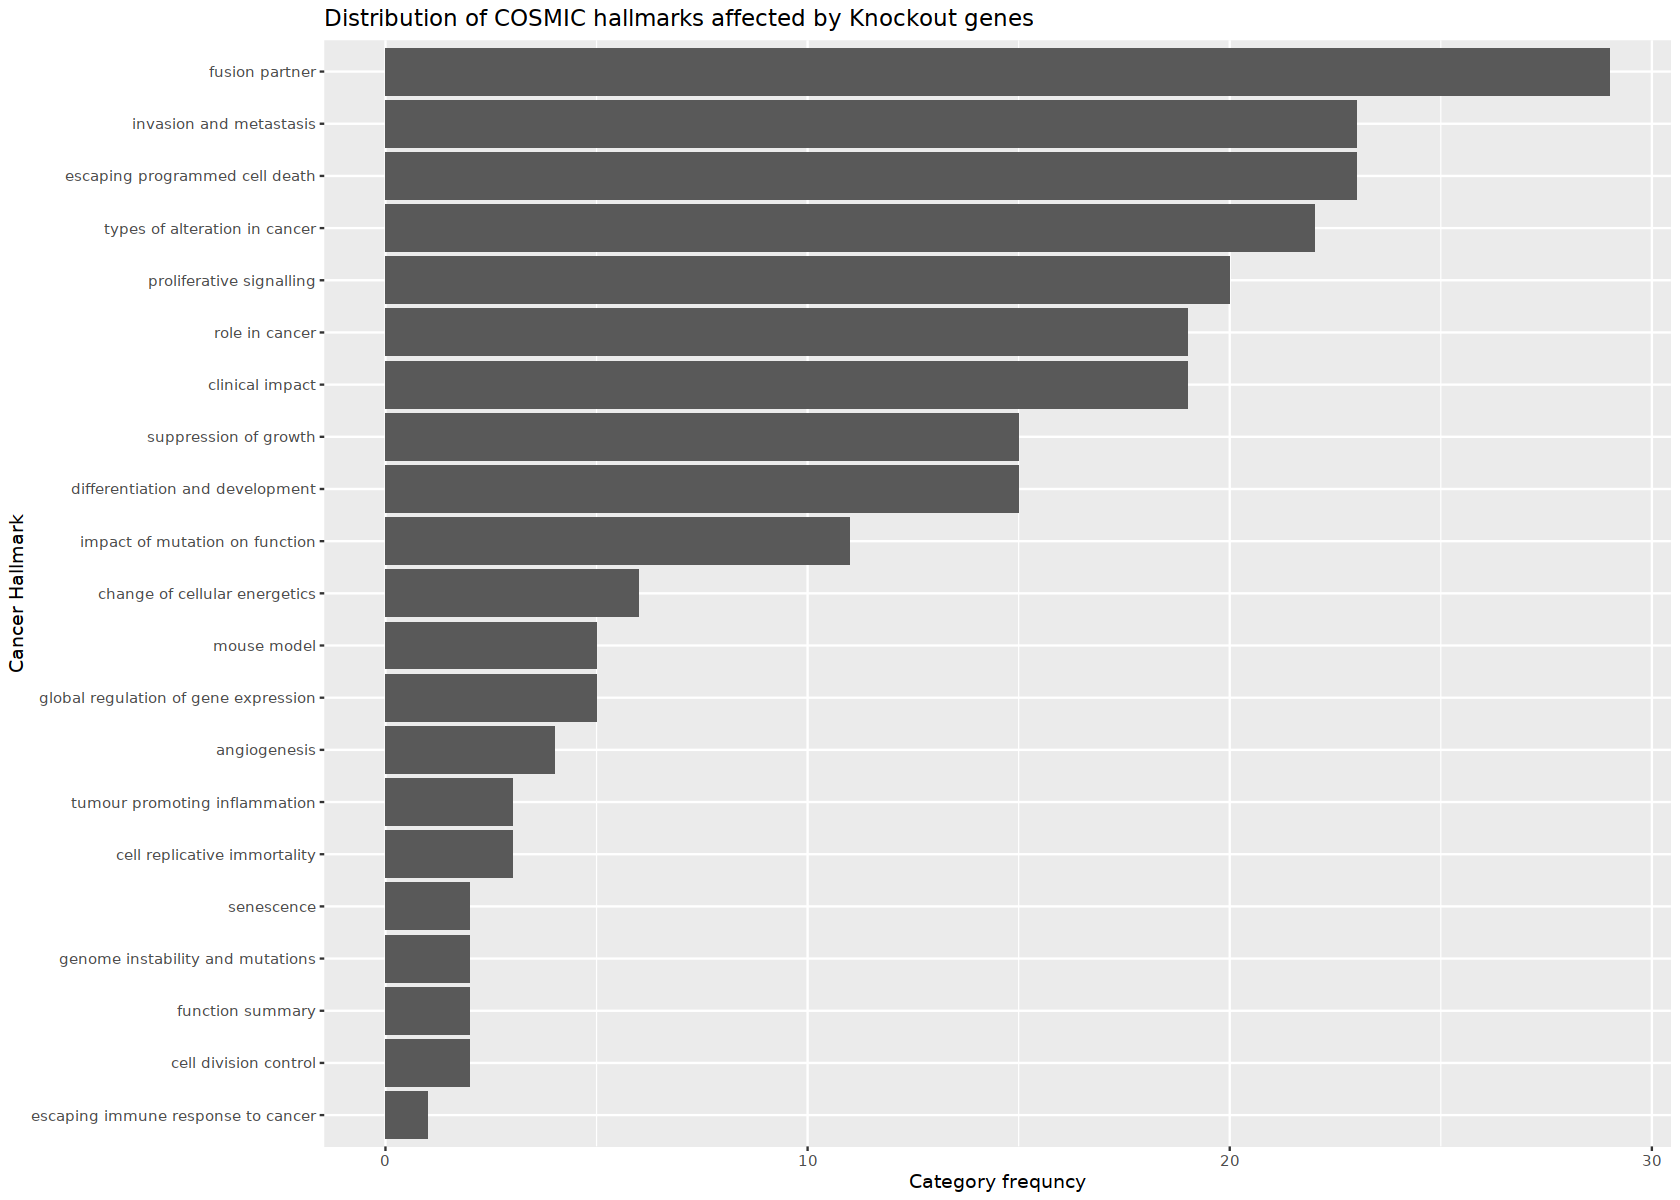

In [150]:
#n = cancer$GENE_NAME %in% genes
cancer_subset <- cancer[cancer$GENE_NAME %in% genes,]
cancer_subset <- cancer_subset[! cancer_subset$CELL_TYPE %in% '']
cancer_plot <- data.frame(table(cancer_subset$HALLMARK))
colnames(cancer_plot) <- c('hallmark', 'frequency')

options(repr.plot.width=14, repr.plot.height=10)
ggplot(cancer_plot, aes(y=reorder(hallmark, frequency), x=frequency)) +
    geom_bar(stat='identity') +
    xlab('Category frequncy') +
    ylab('Cancer Hallmark') +
    ggtitle('Distribution of COSMIC hallmarks affected by Knockout genes')

In [57]:
samples <- fread('/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/samples/09_final_qc.keep.sample_list')

In [60]:
sum(unique(d$s) %in% samples$V1)

[1] 176929

In [ ]:
unique(d$s) %in% samples$V1

In [35]:
d

gene_id,s,phase1,phase2,knockout,csqs
<chr>,<int>,<chr>,<chr>,<lgl>,<chr>
ENSG00000012779,1017198,"[""chr10_45374384_GCA_G""]",NA,FALSE,HE
ENSG00000012779,1035624,"[""chr10_45440563_C_T""]",NA,FALSE,HE
ENSG00000012779,1065696,"[""chr10_45444141_A_G""]",NA,FALSE,HE
ENSG00000012779,1093101,"[""chr10_45424138_A_G""]",NA,FALSE,HE
ENSG00000012779,1106950,"[""chr10_45440585_T_A""]",NA,FALSE,HE
ENSG00000012779,1117792,"[""chr10_45424138_A_G""]",NA,FALSE,HE
ENSG00000012779,1138257,"[""chr10_45440585_T_G""]",NA,FALSE,HE
ENSG00000012779,1143156,"[""chr10_45440563_C_T""]",NA,FALSE,HE
ENSG00000012779,1144531,"[""chr10_45445617_G_A""]",NA,FALSE,HE
